In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
df = pd.read_csv("../data/video_features_output.csv")

## Map confidence & difficulty levels to 3 classes

In [13]:
def map_levels(x):
    if x in [1, 2]:
        return "low"
    elif x == 3:
        return "medium"
    elif x in [4, 5]:
        return "high"

In [14]:
df["confidence_level"] = df["confidence"].apply(map_levels)
df["difficulty_level"] = df["difficulty"].apply(map_levels)

## Inspect Box Plots

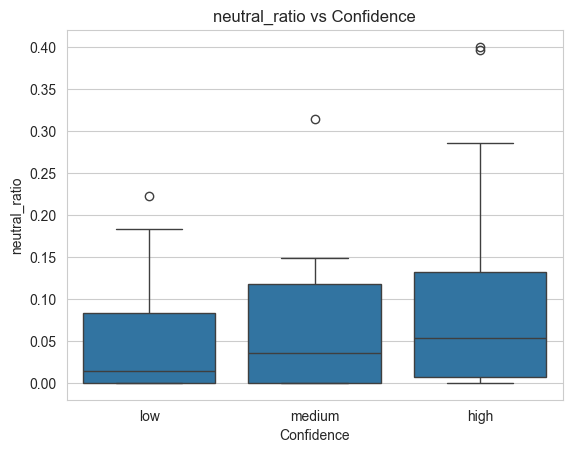

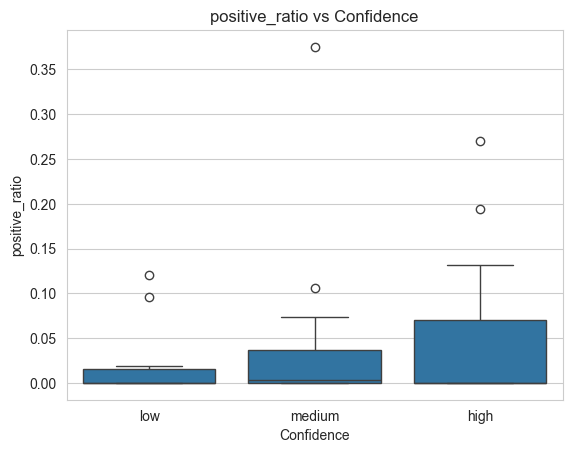

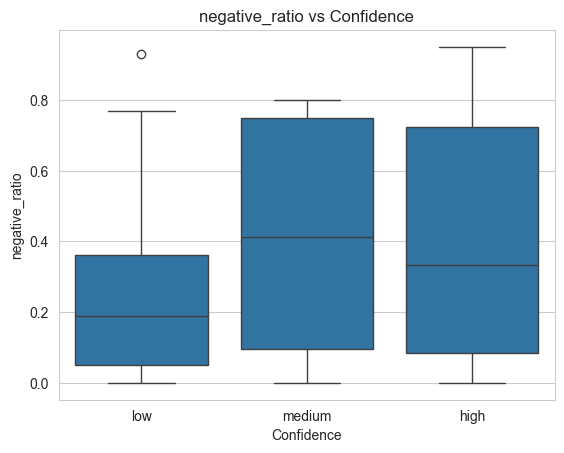

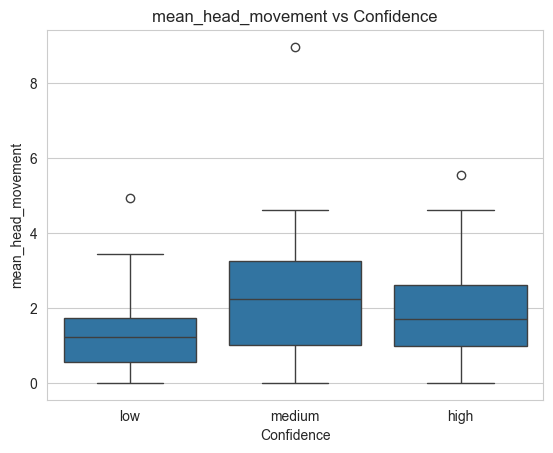

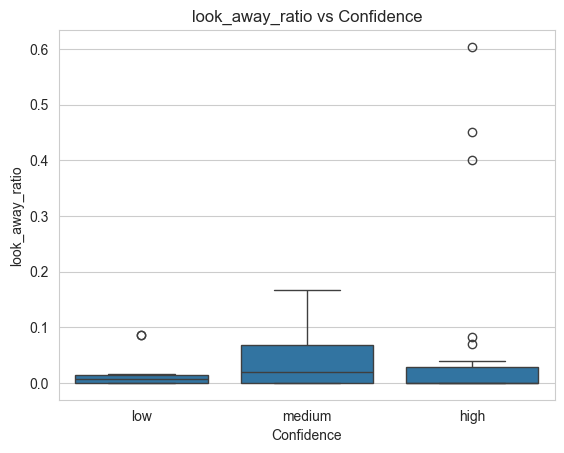

In [21]:
features = [
    "neutral_ratio",
    "positive_ratio",
    "negative_ratio",
    "mean_head_movement",
    "look_away_ratio"
]

for feature in features:
    plt.figure()
    sns.boxplot(x="confidence_level", y=feature, data=df, order = ["low", "medium", "high"])
    plt.title(f"{feature} vs Confidence")
    plt.xlabel("Confidence")
    plt.ylabel(feature)
    plt.show()

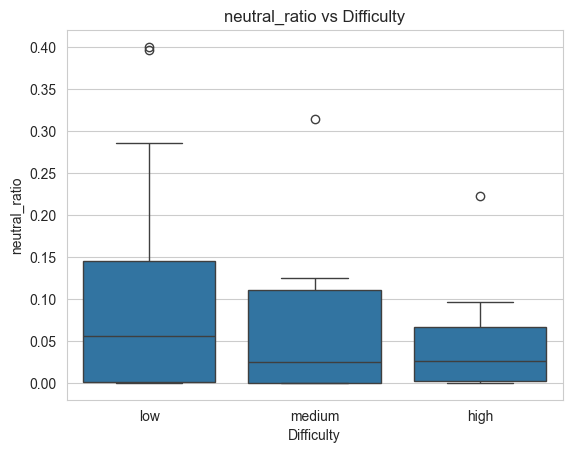

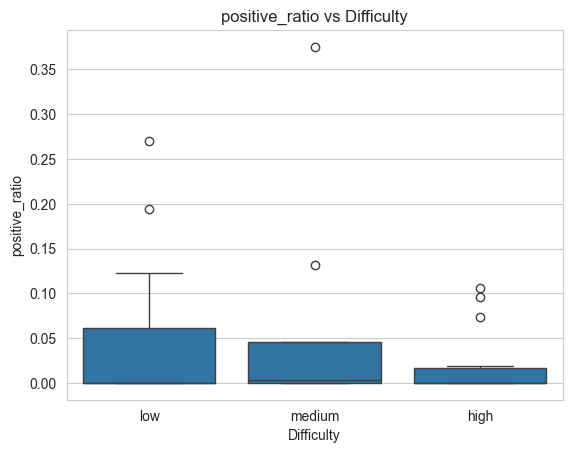

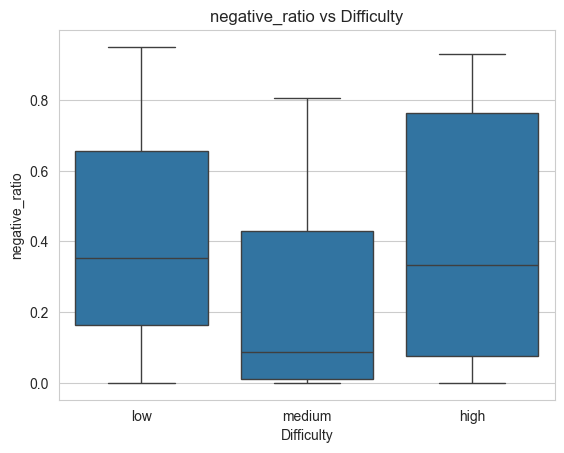

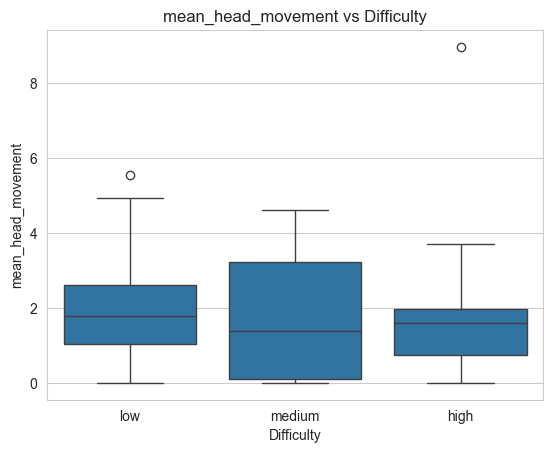

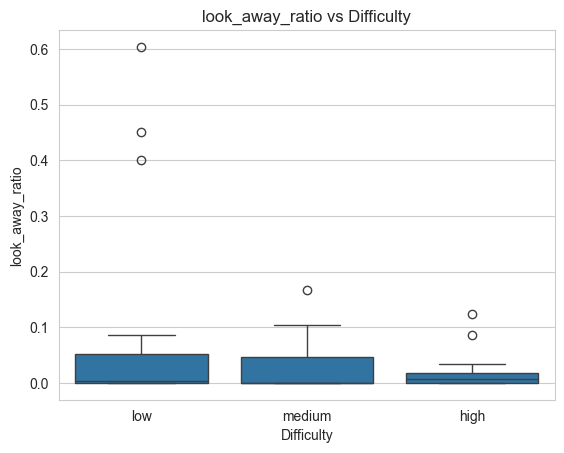

In [22]:
for feature in features:
    plt.figure()
    sns.boxplot(x="difficulty_level", y=feature, data=df, order = ["low", "medium", "high"])
    plt.title(f"{feature} vs Difficulty")
    plt.xlabel("Difficulty")
    plt.ylabel(feature)
    plt.show()

## Statistical Significance 

In [19]:
from scipy.stats import kruskal

for feature in features:
    groups = [group[feature].dropna().values 
              for _, group in df.groupby("confidence_level")]

    stat, p = kruskal(*groups)
    print(f"{feature}: p={p:.4f}")

neutral_ratio: p=0.4910
positive_ratio: p=0.8682
negative_ratio: p=0.6188
mean_head_movement: p=0.4914
look_away_ratio: p=0.4836


In [20]:
from scipy.stats import kruskal

for feature in features:
    groups = [group[feature].dropna().values 
              for _, group in df.groupby("difficulty_level")]

    stat, p = kruskal(*groups)
    print(f"{feature}: p={p:.4f}")

neutral_ratio: p=0.3834
positive_ratio: p=0.8639
negative_ratio: p=0.4742
mean_head_movement: p=0.7641
look_away_ratio: p=0.9058
